# List of unique cities of customers

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """ select distinct customer_city as CustomerCity from ecommerce.customers"""
cur.execute(query)
data=cur.fetchall()
data



[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

# 2. Count the number of orders placed in 2017.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """ select count(order_id)  from orders where year(order_purchase_timestamp)=2017"""
cur.execute(query)
data=cur.fetchall()
data[0][0]



270606

# 3. Find the total sales per category.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """ select products.product_category category,round(sum(payments.payment_value),2) total_sales from products join order_items 
on products.product_id=order_items.product_id join payments on payments.order_id=order_items.order_id
group by category"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
print(df)




                              0             1
0                     perfumery  7.601080e+07
1          Furniture Decoration  2.145265e+08
2                     telephony  7.303231e+07
3                bed table bath  2.568831e+08
4                    automotive  1.278441e+08
..                          ...           ...
69               cds music dvds  1.799145e+05
70                   La Cuisine  4.370295e+05
71  Fashion Children's Clothing  1.178505e+05
72                     PC Gamer  3.261645e+05
73       insurance and services  4.867650e+04

[74 rows x 2 columns]


# 5.Count of customers from each state

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """select customer_state,count(customer_id) from customers group by customer_state order by count(customer_id) asc;"""
cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data)
print(df)



     0       1
0   RR     276
1   AP     408
2   AC     486
3   AM     888
4   RO    1518
5   TO    1680
6   SE    2100
7   AL    2478
8   RN    2910
9   PI    2970
10  PB    3216
11  MS    4290
12  MA    4482
13  MT    5442
14  PA    5850
15  CE    8016
16  PE    9912
17  GO   12120
18  ES   12198
19  DF   12840
20  BA   20280
21  SC   21822
22  PR   30270
23  RS   32796
24  MG   69810
25  RJ   77112
26  SP  250476


# INTERMEDIATE

# 1.Number of orders per month in 2018

       Month  Number of orders
0    January             43614
1   February             40368
2      March             43266
3      April             41634
4        May             41238
5       June             37002
6       July             37752
7     August             39072
8  September                96
9    October                24


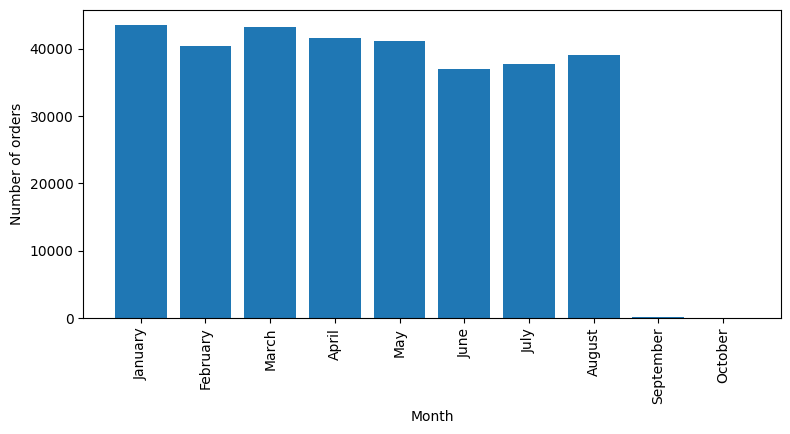

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """select monthname(order_purchase_timestamp) month_name,count(*)   Number_of_orders_in_the_month
  from orders  where year(order_purchase_timestamp)=2018
  group by   month(order_purchase_timestamp), monthname(order_purchase_timestamp) 
  order by  month(order_purchase_timestamp);"""
cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data,columns=["Month","Number of orders"])
print(df)
plt.figure(figsize=(9,4))
plt.bar(df["Month"],df["Number of orders"])
plt.xticks(rotation=90)
plt.xlabel("Month")
plt.ylabel("Number of orders")
plt.show()




# 2.Average number of products per order grouped by customer city


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """with count_per_order as 
(select orders.order_id,orders.customer_id,count(order_items.order_id) as OC
from orders join order_items 
on orders.order_id=order_items.order_id
group by orders.order_id,orders.customer_id)
select customers.customer_city, avg(count_per_order.OC) from customers
join count_per_order on count_per_order.customer_id=customers.customer_id
group by customer_city
order by avg(count_per_order.OC) asc;"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["customer city","avg product count per order"])
print(df)




              customer city avg product count per order
0                    coreau                     30.0000
1             alto sao joao                     30.0000
2     campo alegre de minas                     30.0000
3             manfrinopolis                     30.0000
4               ulianopolis                     30.0000
...                     ...                         ...
4105         matias olimpio                    150.0000
4106          candido godoi                    180.0000
4107                  datas                    180.0000
4108            celso ramos                    195.0000
4109         padre carvalho                    210.0000

[4110 rows x 2 columns]


# 3.Percentage of total revenue contributed by each product category:

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """with sales_per_category as (select products.product_category category,round(sum(payments.payment_value),2) total_sales 
from products join order_items 
on products.product_id=order_items.product_id join payments on payments.order_id=order_items.order_id
group by category)
select category,total_sales,(total_sales/sum(total_sales) over())*100 from sales_per_category """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
print(df)



                              0             1         2
0                     perfumery  7.601080e+07  2.495250
1          Furniture Decoration  2.145265e+08  7.042382
2                     telephony  7.303231e+07  2.397473
3                bed table bath  2.568831e+08  8.432846
4                    automotive  1.278441e+08  4.196812
..                          ...           ...       ...
69               cds music dvds  1.799145e+05  0.005906
70                   La Cuisine  4.370295e+05  0.014347
71  Fashion Children's Clothing  1.178505e+05  0.003869
72                     PC Gamer  3.261645e+05  0.010707
73       insurance and services  4.867650e+04  0.001598

[74 rows x 3 columns]


# 4.Identify the correlation between the price of the product and the number of times a product has been purchased

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """select products.product_category,count(order_items.product_id),
avg(order_items.price) from products join order_items
on products.product_id=order_items.product_id
group by products.product_category; """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["  Product category ","  Number_of_times_bought ","  Product_price "])
print(df)
arr1=df["  Number_of_times_bought "]
arr2=df["  Product_price "]
a=np.corrcoef([arr1,arr2])
print(a)


             Product category   Number_of_times_bought   Product_price 
0                HEALTH BEAUTY                   290100      130.163531
1                sport leisure                   259230      114.344285
2                   Cool Stuff                   113880      167.357969
3         computer accessories                   234810      116.513903
4              Watches present                   179730      201.135984
..                         ...                      ...             ...
69  CITTE AND UPHACK FURNITURE                     1140      114.949473
70             Hygiene diapers                     1170       40.194615
71                     flowers                      990       33.637576
72      insurance and services                       60      141.644997
73              cds music dvds                      420       52.142857

[74 rows x 3 columns]
[[ 1.         -0.10631552]
 [-0.10631552  1.        ]]


# 5.Calculate the total revenue by each seller and rank them by revenue

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """select sellers.seller_id,count(order_items.seller_id),sum(price+freight_value),rank() 
over(order by sum(price+freight_value) desc)
from sellers join order_items
on sellers.seller_id=order_items.seller_id group by sellers.seller_id"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Seller_id "," Number of products sold","Revenue_generated","Seller_rank"])
print(df)



                            Seller_id    Number of products sold  \
0     4869f7a5dfa277a7dca6462dcf3b52b2                     34680   
1     7c67e1448b00f6e969d365cea6b010ab                     40920   
2     53243585a1d6dc2643021fd1853d8905                     12300   
3     4a3ca9315b744ce9f8e9374361493884                     59610   
4     fa1c13f2614d7b5c4749cbc52fecda94                     17580   
...                                ...                       ...   
3090  702835e4b785b67a084280efca355756                        30   
3091  4965a7002cca77301c82d3f91b82e1a9                        30   
3092  1fa2d3def6adfa70e58c276bb64fe5bb                        30   
3093  77128dec4bec4878c37ab7d6169d6f26                        30   
3094  cf6f6bc4df3999b9c6440f124fb2f687                        30   

      Revenue_generated  Seller_rank  
0          7.489221e+06            1  
1          7.186093e+06            2  
2          7.075700e+06            3  
3          7.066199e+06    

# Advanced

# 1.moving average of order_values of each customer over their order history

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """SELECT 
    customer_id,
    order_purchase_timestamp,
    payment_value,
    AVG(payment_value) OVER (
        PARTITION BY customer_id 
        ORDER BY order_purchase_timestamp
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS mov_avg
FROM (
    SELECT 
        o.customer_id,
        o.order_purchase_timestamp,
        SUM(p.payment_value) AS payment_value
    FROM ecommerce.orders o
    JOIN ecommerce.payments p
        ON p.order_id = o.order_id
    GROUP BY o.customer_id, o.order_id, o.order_purchase_timestamp
) AS a;

"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
print(df)



                                      0                    1            2  \
0      00012a2ce6f8dcda20d059ce98491703  2017-11-14 16:08:26  3442.199936   
1      000161a058600d5901f007fab4c27140  2017-07-16 09:40:32  2022.300110   
2      0001fd6190edaaf884bcaf3d49edf079  2017-02-28 11:06:43  5862.599945   
3      0002414f95344307404f0ace7a26f1d5  2017-08-16 13:09:20  5380.500183   
4      000379cdec625522490c315e70c7a9fb  2018-04-02 13:42:17  3210.300064   
...                                 ...                  ...          ...   
99435  fffecc9f79fd8c764f843e9951b11341  2018-03-29 16:59:26  2440.800093   
99436  fffeda5b6d849fbd39689bb92087f431  2018-05-22 13:36:02  1893.900032   
99437  ffff42319e9b2d713724ae527742af25  2018-06-13 16:57:05  6423.900146   
99438  ffffa3172527f765de70084a7e53aae8  2017-09-02 11:53:32  1365.000000   
99439  ffffe8b65bbe3087b653a978c870db99  2017-09-29 14:07:03   551.100025   

                 3  
0      3442.199936  
1      2022.300110  
2      5862.

# 2.Cumulitive sales per month for each year

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """ select Year,Month,Monthly_payment,sum(Monthly_payment)
 over ( partition by Year order by Year,Month) as Cumulative_payments from
 (select year(order_purchase_timestamp) as Year,
 month(order_purchase_timestamp) as Month,
 round(sum(payment_value),2) as Monthly_payment from 
 ecommerce.orders join ecommerce.payments
 on orders.order_id=payments.order_id
 group by Year,Month order by Year,Month) as a;
"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Year","Month","Monthly_Sales","Cumulative_Sales"])
print(df)
print(" ")

# Year Over year growth  :


data1=df.groupby("Year", as_index=False).tail(1)
print(data1)
data1["Year over year growth"]= data1["Cumulative_Sales"].pct_change() * 100
print(" ")
print(data1)



    Year  Month  Monthly_Sales  Cumulative_Sales
0   2016      9        7567.20      7.567200e+03
1   2016     10     1772714.40      1.780282e+06
2   2016     12         588.60      1.780870e+06
3   2017      1     4154641.20      4.154641e+06
4   2017      2     8757240.29      1.291188e+07
5   2017      3    13495907.99      2.640779e+07
6   2017      4    12533640.88      3.894143e+07
7   2017      5    17787564.60      5.672899e+07
8   2017      6    15338291.41      7.206729e+07
9   2017      7    17771487.58      8.983877e+07
10  2017      8    20231889.60      1.100707e+08
11  2017      9    21832873.51      1.319035e+08
12  2017     10    23390336.39      1.552939e+08
13  2017     11    35846483.99      1.911404e+08
14  2017     12    26352044.40      2.174924e+08
15  2018      1    33450125.37      3.345013e+07
16  2018      2    29773900.20      6.322403e+07
17  2018      3    34789563.59      9.801359e+07
18  2018      4    34823564.42      1.328372e+08
19  2018      5    3

C:\Users\User\AppData\Local\Temp\ipykernel_328\2589213023.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1["Year over year growth"]= data1["Cumulative_Sales"].pct_change() * 100


# 3.Calculate the year over year growth:

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """with a as  
 (select year(order_purchase_timestamp) as Year,
 round(sum(payment_value),2) as Yearly_payment from 
 ecommerce.orders join ecommerce.payments
 on orders.order_id=payments.order_id
 group by Year order by Year) 
 select Year,Yearly_payment,
 (Yearly_payment-lag(Yearly_payment,1) over(order by Year))/(lag(Yearly_payment,1) over(order by Year)) *100 as YoY_Growth from a
"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Year","Yearly_payment","YoY_%_Growth"])
print(df)
print(" ")

   Year  Yearly_payment  YoY_%_Growth
0  2016    1.780870e+06           NaN
1  2017    2.174924e+08  12112.703759
2  2018    2.609929e+08     20.000924
 


# 4.Calculate the retention rate of customers defined as the percentage of customers who make another purchase within 6 months of their first purchase: 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """with a as (select customers.customer_id,min(orders.order_purchase_timestamp) as first_order
from
customers join orders
on customers.customer_id=orders.customer_id
group by customer_id),
  b as (select a.customer_id,count(distinct orders.order_purchase_timestamp)
 from a join orders 
 on a.customer_id=orders.customer_id
 and orders.order_purchase_timestamp > first_order
 and orders.order_purchase_timestamp < date_add(first_order, interval 6 month)
 group by a.customer_id)
 
 select 100*( count(distinct b.customer_id))/(count(distinct a.customer_id))
 from a left join b
 on a.customer_id=b.customer_id
 ;
"""
cur.execute(query)
data=cur.fetchall()
df = pd.DataFrame(data, columns=["Repeat Customer %"])
print(df)


  Repeat Customer %
0            0.0000


# 5.Identify top 3 customers who spent most money every year:

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db=mysql.connector.connect( host="localhost",
                            username="root",
                            password="PASSWORD@629",
                            database="ecommerce")
cur = db.cursor()

query= """WITH a AS (
    SELECT 
        orders.customer_id ,
        YEAR(orders.order_purchase_timestamp) AS Year,
        SUM(payments.payment_value) AS total_money_spent
    FROM ecommerce.orders
    JOIN ecommerce.payments
        ON orders.order_id = payments.order_id
    GROUP BY orders.customer_id, YEAR(orders.order_purchase_timestamp)
),
 b as(SELECT 
customer_id,
Year,
total_money_spent,
dense_rank()
over(partition by Year order by total_money_spent desc) as Yearly_ranking
FROM a
)
select *
From b where Yearly_ranking<=3
order by Year,Yearly_ranking
 ;
"""
cur.execute(query)
data=cur.fetchall()
df = pd.DataFrame(data, columns=["Customer_id","Year","Money_spent","Yearly_Ranking"])
print(df)

                        Customer_id  Year    Money_spent  Yearly_Ranking
0  a9dc96b027d1252bbac0a9b72d837fc6  2016   42706.501465               1
1  1d34ed25963d5aae4cf3d7f3a4cda173  2016   42022.199707               2
2  4a06381959b6670756de02e07b83815f  2016   36833.400879               3
3  1617b1357756262bfa56ab541c47bc16  2017  409922.402344               1
4  c6e2731c5b391845f6800c97401a43a9  2017  207879.301758               2
5  3fd6777bbce08a352fddd04e4a7cc8f6  2017  201799.804688               3
6  ec5b2ba62e574342386871631fafd3fc  2018  218246.396484               1
7  f48d464a0baaea338cb25f816991ab1f  2018  207666.298828               2
8  e0a2412720e9ea4f26c1ac985f6a7358  2018  144283.198242               3
